# Exploratory Data Analysis of Seismic Signals (HDF5)

This notebook performs AED on the signals stored in `data/processed/signals_test.hdf5`.

## Objectives:
1. Load and inspect the HDF5 file structure
2. Examine metadata (intervals, labels, event properties)
3. Analyze signal characteristics (duration, sampling rate, etc.)
4. Visualize sample waveforms for events and non-events
5. Compare event vs non-event signal patterns

In [16]:
# Import required libraries
import sys
from pathlib import Path
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from obspy import Trace, Stream

# Add parent directory to path
sys.path.insert(0, str(Path.cwd().parent))

from config.config import PROCESSED_DATA_PATH

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 5)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [17]:
# Load HDF5 file
hdf5_file = Path(PROCESSED_DATA_PATH) / "signals_test.hdf5"

# Alternative: Use absolute path if config path doesn't work
if not hdf5_file.exists():
    hdf5_file = Path("../data/processed/signals_test.hdf5")

if not hdf5_file.exists():
    print(f"✗ File not found: {hdf5_file}")
    print(f"  Tried: {Path(PROCESSED_DATA_PATH) / 'signals_test.hdf5'}")
    print(f"  Also tried: ../data/processed/signals_test.hdf5")
    print("  Please run scripts/get_signals.py first")
else:
    print(f"✓ HDF5 file found: {hdf5_file}")
    file_size_mb = hdf5_file.stat().st_size / (1024 * 1024)
    print(f"  File size: {file_size_mb:.2f} MB")
    
    # Open and explore file structure
    with h5py.File(hdf5_file, 'r') as hf:
        print(f"\n📁 HDF5 File Structure:")
        print(f"  Top-level groups: {list(hf.keys())}")
        
        # Metadata info
        if 'metadata' in hf:
            print(f"\n  Metadata datasets: {list(hf['metadata'].keys())}")
            n_intervals = len(hf['metadata']['id'])
            print(f"  Number of intervals: {n_intervals}")
        
        # Signals info
        if 'signals' in hf:
            signal_ids = list(hf['signals'].keys())
            print(f"\n  Number of stored signals: {len(signal_ids)}")
            print(f"  Sample signal IDs: {signal_ids[:5]}")

✓ HDF5 file found: ..\data\processed\signals_test.hdf5
  File size: 1.36 MB

📁 HDF5 File Structure:
  Top-level groups: ['metadata', 'signals']

  Metadata datasets: ['date', 'duration', 'end_time', 'id', 'label', 'lat', 'long', 'mag', 'start_time']
  Number of intervals: 36

  Number of stored signals: 36
  Sample signal IDs: ['non_event_17', 'non_event_20', 'non_event_22', 'non_event_27', 'non_event_31']


In [3]:
# Load metadata into DataFrame
with h5py.File(hdf5_file, 'r') as hf:
    metadata_dict = {}
    for key in hf['metadata'].keys():
        data = hf['metadata'][key][:]
        # Decode bytes to string if necessary
        if data.dtype.kind == 'S':
            data = np.array([d.decode('utf-8') if d else '' for d in data])
        metadata_dict[key] = data
    
    metadata_df = pd.DataFrame(metadata_dict)

# Convert datetime columns
for col in ['start_time', 'end_time', 'date']:
    if col in metadata_df.columns:
        metadata_df[col] = pd.to_datetime(metadata_df[col])

# Convert numeric columns
for col in ['lat', 'long', 'mag', 'label', 'duration']:
    if col in metadata_df.columns:
        metadata_df[col] = pd.to_numeric(metadata_df[col], errors='coerce')

print("📊 Metadata Summary:")
print(f"  Shape: {metadata_df.shape}")
print(f"\nColumns: {list(metadata_df.columns)}")
print(f"\nFirst few rows:")
display(metadata_df.head())

print(f"\n📈 Data types:")
print(metadata_df.dtypes)

📊 Metadata Summary:
  Shape: (36, 9)

Columns: ['date', 'duration', 'end_time', 'id', 'label', 'lat', 'long', 'mag', 'start_time']

First few rows:


,date,duration,end_time,id,label,lat,long,mag,start_time
0,2025-04-26 19:11:28.166,167.325478,2025-04-26 19:13:06.498862,query?eventid=11969923,1,-19.0714,-70.0864,4.3,2025-04-26 19:10:19.173384
1,2025-05-26 03:50:25.655,55.783205,2025-05-26 03:50:57.840666,query?eventid=11974501,1,-19.6169,-69.4508,5.7,2025-05-26 03:50:02.057461
2,2025-03-07 13:08:10.125,157.696066,2025-03-07 13:09:51.502406,query?eventid=11944017,1,-19.6847,-69.1931,4.2,2025-03-07 13:07:13.806340
3,2025-01-10 02:16:38.315,196.010459,2025-01-10 02:18:37.854394,query?eventid=11922231,1,-19.3316,-69.2982,4.4,2025-01-10 02:15:21.843935
4,2025-05-07 23:04:51.200,157.516640,2025-05-07 23:06:48.026072,query?eventid=11968097,1,-19.3779,-67.9592,4.3,2025-05-07 23:04:10.509432



📈 Data types:
date          datetime64[ns]
duration             float64
end_time      datetime64[ns]
id                    object
label                  int64
lat                  float64
long                 float64
mag                  float64
start_time    datetime64[ns]
dtype: object


LABEL DISTRIBUTION

Event (1): 18
Non-event (0): 18
Total: 36


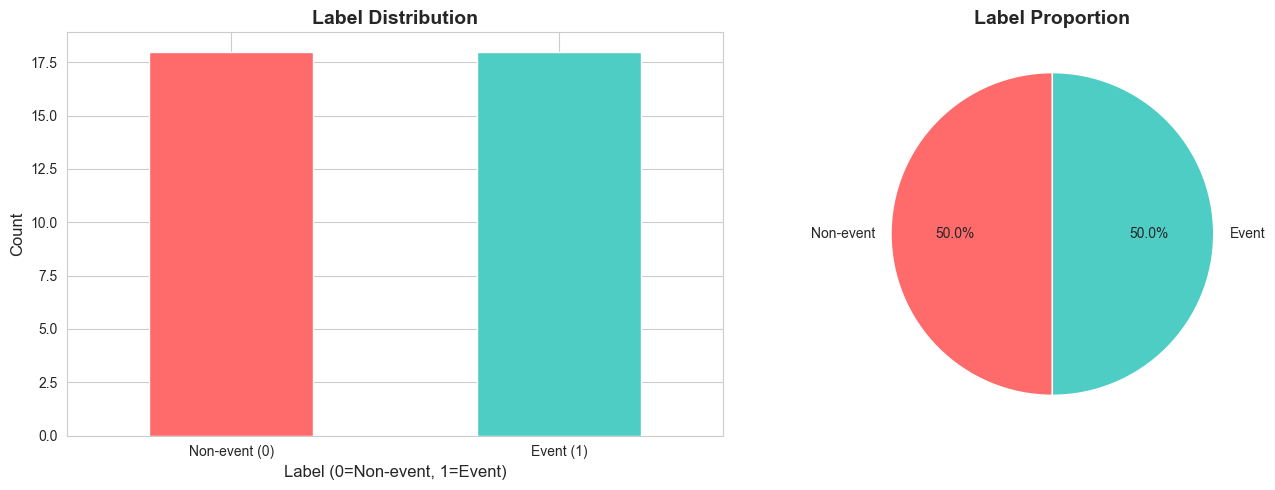


DURATION STATISTICS

Overall Duration Statistics:
count     36.000000
mean     109.463551
std       49.149594
min       19.814899
25%       72.451765
50%      114.131488
75%      142.479101
max      204.061771
Name: duration, dtype: float64

Duration by Label:
       count        mean        std        min        25%         50%  \
label                                                                   
0       18.0  105.505587  42.989329  40.000000  73.231012  109.136984   
1       18.0  113.421515  55.607624  19.814899  70.691168  119.926562   

              75%         max  
label                          
0      126.072569  192.413034  
1      157.651209  204.061771  

EVENT CHARACTERISTICS (Label=1)

Number of events: 18

Magnitude statistics:
count    18.000000
mean      4.455556
std       0.599237
min       3.400000
25%       4.050000
50%       4.350000
75%       4.725000
max       5.700000
Name: mag, dtype: float64

Location range:
  Latitude: -20.6580 to -18.7955
  Longitude

In [4]:
# Statistical Analysis of Metadata

print("=" * 70)
print("LABEL DISTRIBUTION")
print("=" * 70)
label_counts = metadata_df['label'].value_counts().sort_index()
print(f"\nEvent (1): {label_counts.get(1, 0)}")
print(f"Non-event (0): {label_counts.get(0, 0)}")
print(f"Total: {len(metadata_df)}")

# Visualize label distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
label_counts.plot(kind='bar', ax=axes[0], color=['#FF6B6B', '#4ECDC4'])
axes[0].set_title('Label Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Label (0=Non-event, 1=Event)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_xticklabels(['Non-event (0)', 'Event (1)'], rotation=0)

# Pie chart
axes[1].pie(label_counts, labels=['Non-event', 'Event'], autopct='%1.1f%%', 
            colors=['#FF6B6B', '#4ECDC4'], startangle=90)
axes[1].set_title('Label Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("DURATION STATISTICS")
print("=" * 70)
if 'duration' in metadata_df.columns:
    print(f"\nOverall Duration Statistics:")
    print(metadata_df['duration'].describe())
    
    print(f"\nDuration by Label:")
    print(metadata_df.groupby('label')['duration'].describe())

print("\n" + "=" * 70)
print("EVENT CHARACTERISTICS (Label=1)")
print("=" * 70)
event_data = metadata_df[metadata_df['label'] == 1]
if len(event_data) > 0:
    print(f"\nNumber of events: {len(event_data)}")
    if 'mag' in event_data.columns:
        print(f"\nMagnitude statistics:")
        print(event_data['mag'].describe())
    if 'lat' in event_data.columns and 'long' in event_data.columns:
        print(f"\nLocation range:")
        print(f"  Latitude: {event_data['lat'].min():.4f} to {event_data['lat'].max():.4f}")
        print(f"  Longitude: {event_data['long'].min():.4f} to {event_data['long'].max():.4f}")

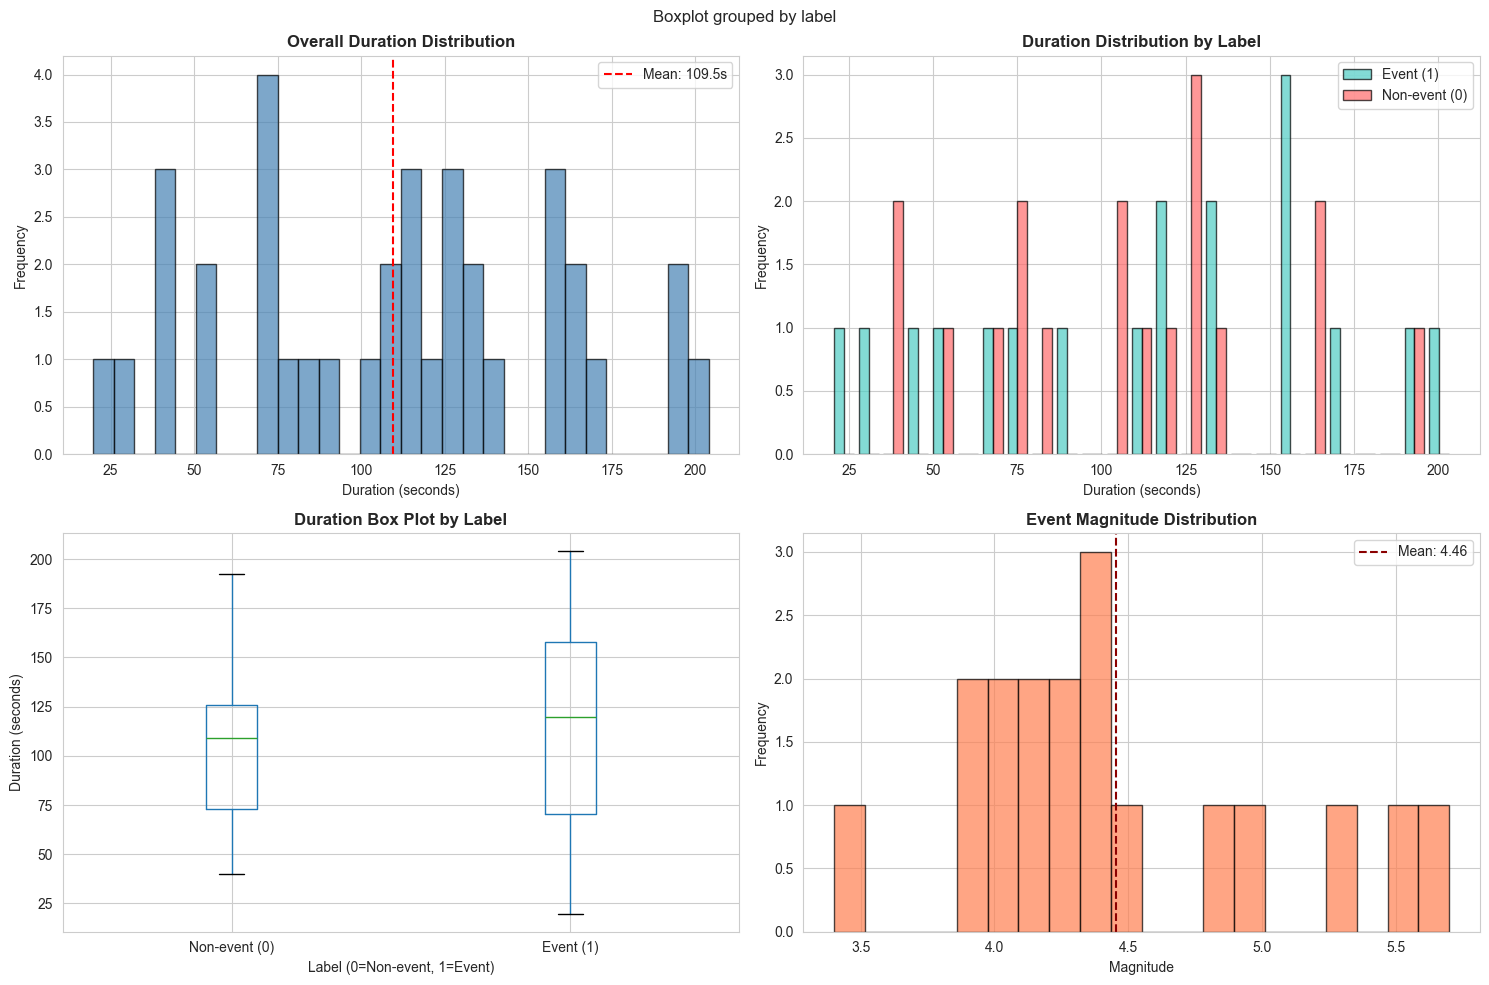

In [5]:
# Visualize Duration Distribution

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Overall duration histogram
if 'duration' in metadata_df.columns:
    axes[0, 0].hist(metadata_df['duration'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0, 0].set_title('Overall Duration Distribution', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Duration (seconds)', fontsize=10)
    axes[0, 0].set_ylabel('Frequency', fontsize=10)
    axes[0, 0].axvline(metadata_df['duration'].mean(), color='red', linestyle='--', 
                       label=f'Mean: {metadata_df["duration"].mean():.1f}s')
    axes[0, 0].legend()

    # Duration by label
    event_durations = metadata_df[metadata_df['label'] == 1]['duration']
    non_event_durations = metadata_df[metadata_df['label'] == 0]['duration']
    
    axes[0, 1].hist([event_durations, non_event_durations], bins=25, 
                    label=['Event (1)', 'Non-event (0)'], color=['#4ECDC4', '#FF6B6B'], 
                    edgecolor='black', alpha=0.7)
    axes[0, 1].set_title('Duration Distribution by Label', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Duration (seconds)', fontsize=10)
    axes[0, 1].set_ylabel('Frequency', fontsize=10)
    axes[0, 1].legend()

    # Box plot comparison
    metadata_df.boxplot(column='duration', by='label', ax=axes[1, 0])
    axes[1, 0].set_title('Duration Box Plot by Label', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Label (0=Non-event, 1=Event)', fontsize=10)
    axes[1, 0].set_ylabel('Duration (seconds)', fontsize=10)
    plt.sca(axes[1, 0])
    plt.xticks([1, 2], ['Non-event (0)', 'Event (1)'])

# Magnitude distribution for events
if 'mag' in metadata_df.columns:
    event_data = metadata_df[metadata_df['label'] == 1]
    axes[1, 1].hist(event_data['mag'].dropna(), bins=20, color='coral', edgecolor='black', alpha=0.7)
    axes[1, 1].set_title('Event Magnitude Distribution', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Magnitude', fontsize=10)
    axes[1, 1].set_ylabel('Frequency', fontsize=10)
    axes[1, 1].axvline(event_data['mag'].mean(), color='darkred', linestyle='--',
                       label=f'Mean: {event_data["mag"].mean():.2f}')
    axes[1, 1].legend()

plt.tight_layout()
plt.show()

## ⚠️ Data Preprocessing Check

**Issue**: The amplitude values are very large (millions), which indicates the data might still be in **raw instrument counts** rather than physical units.

**Expected after preprocessing**:
- Raw data: Values in millions (instrument counts)
- Preprocessed data: Values typically between 1e-9 to 1e-3 meters (displacement units)

The preprocessing steps should:
1. **Demean**: Remove the mean value
2. **Detrend (linear)**: Remove linear trends
3. **Remove instrument response**: Convert from counts to displacement (meters)

Let's check if the data has actually been preprocessed:

In [6]:
# Analyze Signal Characteristics

print("=" * 70)
print("SIGNAL CHARACTERISTICS ANALYSIS")
print("=" * 70)

signal_info = []

with h5py.File(hdf5_file, 'r') as hf:
    if 'signals' in hf:
        signal_ids = list(hf['signals'].keys())
        
        print(f"\nAnalyzing {len(signal_ids)} signals...")
        
        for sig_id in signal_ids:
            sig_group = hf['signals'][sig_id]
            
            # Get label
            label = sig_group.attrs.get('label', None)
            num_traces = sig_group.attrs.get('num_traces', 0)
            
            # Get magnitude from metadata
            mag = metadata_df[metadata_df['id'] == sig_id]['mag'].values
            mag = mag[0] if len(mag) > 0 else None
            
            # Analyze each trace
            for trace_name in sig_group.keys():
                trace_group = sig_group[trace_name]
                
                if 'data' in trace_group:
                    data = trace_group['data'][:]
                    sampling_rate = trace_group.attrs.get('sampling_rate', None)
                    channel = trace_group.attrs.get('channel', '').decode('utf-8') if isinstance(trace_group.attrs.get('channel'), bytes) else trace_group.attrs.get('channel', '')
                    preprocessed = trace_group.attrs.get('preprocessed', False)
                    
                    signal_info.append({
                        'interval_id': sig_id,
                        'label': label,
                        'mag': mag,
                        'trace': trace_name,
                        'num_points': len(data),
                        'sampling_rate': sampling_rate,
                        'duration_s': len(data) / sampling_rate if sampling_rate else None,
                        'mean_amplitude': np.mean(data),
                        'std_amplitude': np.std(data),
                        'min_amplitude': np.min(data),
                        'max_amplitude': np.max(data),
                        'channel': channel,
                        'preprocessed': preprocessed
                    })

signal_df = pd.DataFrame(signal_info)

print(f"\n✓ Analyzed {len(signal_df)} traces from {len(signal_ids)} intervals")
print(f"\nSignal DataFrame shape: {signal_df.shape}")
print(f"\nFirst few rows:")
display(signal_df.head(10))

print(f"\n📊 Signal Statistics by Label:")
print(signal_df.groupby('label')[['num_points', 'sampling_rate', 'duration_s', 'std_amplitude']].describe())

print(f"\n🌍 Magnitude Analysis:")
event_signals = signal_df[signal_df['label'] == 1].copy()
if len(event_signals) > 0 and 'mag' in event_signals.columns:
    print(f"\nEvent signals with magnitude data: {event_signals['mag'].notna().sum()}")
    if event_signals['mag'].notna().sum() > 0:
        print(f"Magnitude range: {event_signals['mag'].min():.2f} - {event_signals['mag'].max():.2f}")
        print(f"Mean magnitude: {event_signals['mag'].mean():.2f}")
        print(f"\nSignal characteristics by magnitude range:")
        event_signals['mag_bin'] = pd.cut(event_signals['mag'], bins=3, labels=['Low', 'Medium', 'High'])
        print(event_signals.groupby('mag_bin')[['std_amplitude', 'mean_amplitude']].mean())

SIGNAL CHARACTERISTICS ANALYSIS

Analyzing 36 signals...

✓ Analyzed 36 traces from 36 intervals

Signal DataFrame shape: (36, 13)

First few rows:


,interval_id,label,mag,trace,num_points,sampling_rate,duration_s,mean_amplitude,std_amplitude,min_amplitude,max_amplitude,channel,preprocessed
0,non_event_17,0,NaN,trace_0,4137,40.0,103.425,-3.407582e-14,72.385847,-269.849750,233.758878,BHZ,False
1,non_event_20,0,NaN,trace_0,5024,40.0,125.600,2.896480e-14,134.119701,-361.602698,420.412601,BHZ,False
2,non_event_22,0,NaN,trace_0,6474,40.0,161.850,1.123874e-14,90.281570,-328.011385,305.679799,BHZ,False
3,non_event_27,0,NaN,trace_0,2090,40.0,52.250,8.703299e-16,94.642964,-298.623069,254.430546,BHZ,False
4,non_event_31,0,NaN,trace_0,3277,40.0,81.925,1.026894e-13,109.659622,-488.203235,326.186221,BHZ,False
5,non_event_37,0,NaN,trace_0,4238,40.0,105.950,-1.030103e-13,99.714333,-316.810776,314.688810,BHZ,False
6,non_event_38,0,NaN,trace_0,4492,40.0,112.300,-4.211374e-14,70.344658,-248.797526,220.187948,BHZ,False
7,non_event_49,0,NaN,trace_0,6443,40.0,161.075,-1.016353e-13,76.680651,-265.081579,274.334991,BHZ,False
8,non_event_53,0,NaN,trace_0,4986,40.0,124.650,6.858604e-14,100.375847,-322.340188,341.777669,BHZ,False
9,non_event_54,0,NaN,trace_0,1600,40.0,40.000,-9.094947e-15,106.798828,-309.099201,320.961085,BHZ,False



📊 Signal Statistics by Label:
      num_points                                                              \
           count         mean          std     min      25%     50%      75%   
label                                                                          
0           18.0  4220.000000  1719.612679  1600.0  2928.75  4365.0  5042.75   
1           18.0  4536.944444  2224.310348   793.0  2827.50  4797.0  6306.25   

              sampling_rate        ... duration_s          std_amplitude  \
          max         count  mean  ...        75%      max         count   
label                              ...                                     
0      7697.0          18.0  40.0  ...  126.06875  192.425          18.0   
1      8162.0          18.0  40.0  ...  157.65625  204.050          18.0   

                                                                          \
                mean            std        min          25%          50%   
label                              

C:\Users\aaron\AppData\Local\Temp\ipykernel_19440\3219491219.py:71: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(event_signals.groupby('mag_bin')[['std_amplitude', 'mean_amplitude']].mean())


In [19]:
# Check if signals are actually preprocessed
print("=" * 70)
print("PREPROCESSING STATUS CHECK")
print("=" * 70)

with h5py.File(hdf5_file, 'r') as hf:
    if 'signals' in hf:
        signal_ids = list(hf['signals'].keys())
        fully_preprocessed_count = 0
        detrended_count = 0
        total_traces = 0
        
        # Sample a few signals to check preprocessing status
        sample_ids = signal_ids[:min(10, len(signal_ids))]
        
        print(f"\nChecking {len(sample_ids)} sample signals...")
        for sig_id in sample_ids:
            sig_group = hf['signals'][sig_id]
            for trace_name in sig_group.keys():
                trace_group = sig_group[trace_name]
                if 'data' in trace_group:
                    total_traces += 1
                    fully_preprocessed = trace_group.attrs.get('preprocessed', False)
                    detrended = trace_group.attrs.get('detrended', False)
                    response_removed = trace_group.attrs.get('response_removed', False)
                    
                    if fully_preprocessed:
                        fully_preprocessed_count += 1
                    if detrended:
                        detrended_count += 1
                    
                    data = trace_group['data'][:]
                    print(f"\n  Signal: {sig_id}, Trace: {trace_name}")
                    print(f"    Detrended: {detrended}, Response removed: {response_removed}")
                    print(f"    Data range: [{np.min(data):.2e}, {np.max(data):.2e}]")
                    print(f"    Mean: {np.mean(data):.2e}, Std: {np.std(data):.2e}")
        
        print(f"\n{'=' * 70}")
        print(f"SUMMARY:")
        print(f"  Detrended (demean + linear): {detrended_count}/{total_traces} traces")
        print(f"  Fully preprocessed (+ response removal): {fully_preprocessed_count}/{total_traces} traces")
        
        if detrended_count == total_traces and fully_preprocessed_count == 0:
            print("\n✓ All traces are DETRENDED (mean removed, linear trend removed)")
            print("  ℹ️  Response removal failed - instrument metadata not available")
            print("  → Data is in DETRENDED COUNTS (not physical units)")
            print("  → Values reduced by ~10,000x compared to raw data")
            print("  → Mean values are now ~0 (successful detrending)")
            print("\n  This is the best preprocessing possible without instrument response metadata.")
        elif fully_preprocessed_count == total_traces:
            print("\n✓ All traces are FULLY PREPROCESSED")
            print("  → Data converted to physical units (displacement in meters)")
            print("  → Expected amplitude range: 1e-9 to 1e-3 m")
        elif detrended_count == 0:
            print("\n⚠️  WARNING: No preprocessing applied!")
            print("   To get preprocessed data:")
            print("   1. Re-run: python scripts/03_get_signals.py")
        else:
            print(f"\n⚠️  MIXED preprocessing status:")
            print(f"   {detrended_count}/{total_traces} detrended")
            print(f"   {fully_preprocessed_count}/{total_traces} fully preprocessed")

PREPROCESSING STATUS CHECK

Checking 10 sample signals...

  Signal: non_event_17, Trace: trace_0
    Detrended: True, Response removed: False
    Data range: [-2.70e+02, 2.34e+02]
    Mean: -3.41e-14, Std: 7.24e+01

  Signal: non_event_20, Trace: trace_0
    Detrended: True, Response removed: False
    Data range: [-3.62e+02, 4.20e+02]
    Mean: 2.90e-14, Std: 1.34e+02

  Signal: non_event_22, Trace: trace_0
    Detrended: True, Response removed: False
    Data range: [-3.28e+02, 3.06e+02]
    Mean: 1.12e-14, Std: 9.03e+01

  Signal: non_event_27, Trace: trace_0
    Detrended: True, Response removed: False
    Data range: [-2.99e+02, 2.54e+02]
    Mean: 8.70e-16, Std: 9.46e+01

  Signal: non_event_31, Trace: trace_0
    Detrended: True, Response removed: False
    Data range: [-4.88e+02, 3.26e+02]
    Mean: 1.03e-13, Std: 1.10e+02

  Signal: non_event_37, Trace: trace_0
    Detrended: True, Response removed: False
    Data range: [-3.17e+02, 3.15e+02]
    Mean: -1.03e-13, Std: 9.97e+0

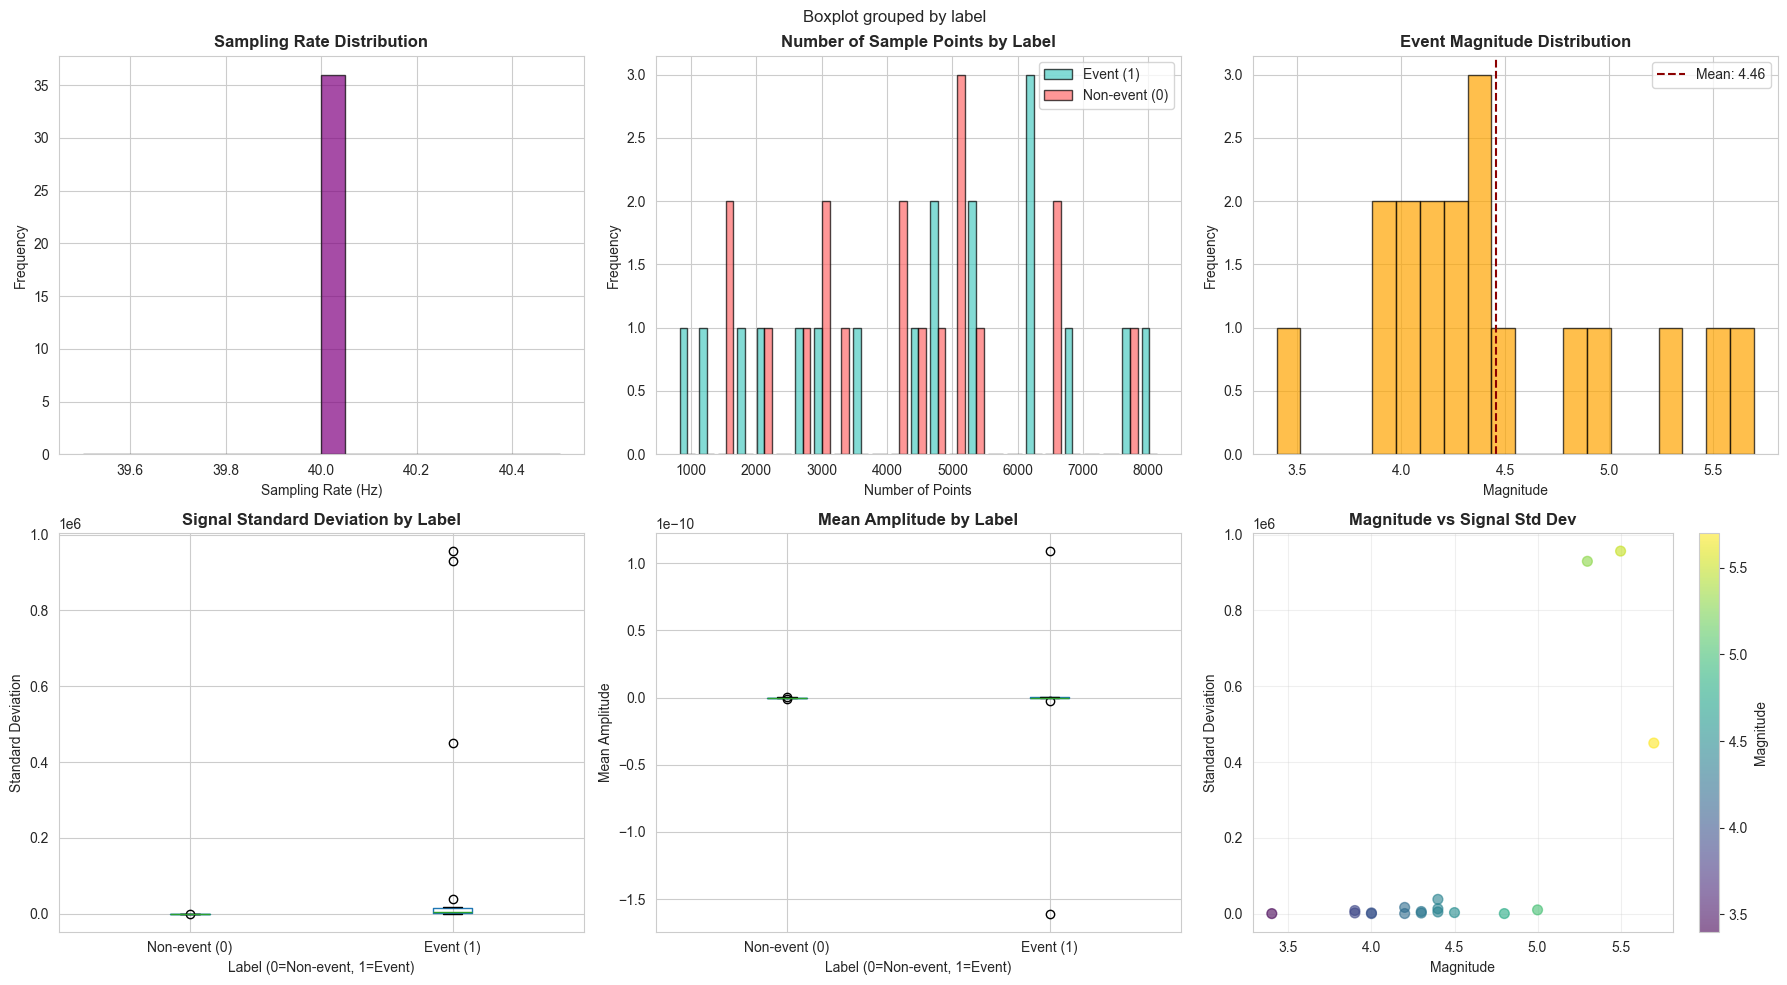


📈 Statistical Comparison (Event vs Non-event):

Standard Deviation:
       count           mean            std        min          25%  \
label                                                                
0       18.0      98.054923      22.390254  70.344658    80.980272   
1       18.0  135555.807807  311888.786976  58.373009  1628.400488   

               50%           75%            max  
label                                            
0        95.257943    106.134588     146.372643  
1      4970.224333  15513.145384  956668.447392  

Mean Amplitude:
       count          mean           std           min           25%  \
label                                                                  
0       18.0 -2.532035e-14  1.949071e-13 -7.089734e-13 -4.010426e-14   
1       18.0 -2.991307e-12  4.702946e-11 -1.608238e-10 -3.528608e-14   

                50%           75%           max  
label                                            
0     -3.464321e-16  2.748788e-14  3.082557e

In [8]:
# Visualize Signal Statistics

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Sampling rate distribution
if 'sampling_rate' in signal_df.columns:
    axes[0, 0].hist(signal_df['sampling_rate'], bins=20, color='purple', edgecolor='black', alpha=0.7)
    axes[0, 0].set_title('Sampling Rate Distribution', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Sampling Rate (Hz)', fontsize=10)
    axes[0, 0].set_ylabel('Frequency', fontsize=10)

# Number of points by label
event_signals = signal_df[signal_df['label'] == 1]
non_event_signals = signal_df[signal_df['label'] == 0]

axes[0, 1].hist([event_signals['num_points'], non_event_signals['num_points']], 
                bins=25, label=['Event (1)', 'Non-event (0)'], 
                color=['#4ECDC4', '#FF6B6B'], edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Number of Sample Points by Label', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Number of Points', fontsize=10)
axes[0, 1].set_ylabel('Frequency', fontsize=10)
axes[0, 1].legend()

# Magnitude distribution for events
if 'mag' in signal_df.columns:
    event_mags = signal_df[signal_df['label'] == 1]['mag'].dropna()
    if len(event_mags) > 0:
        axes[0, 2].hist(event_mags, bins=20, color='orange', edgecolor='black', alpha=0.7)
        axes[0, 2].set_title('Event Magnitude Distribution', fontsize=12, fontweight='bold')
        axes[0, 2].set_xlabel('Magnitude', fontsize=10)
        axes[0, 2].set_ylabel('Frequency', fontsize=10)
        axes[0, 2].axvline(event_mags.mean(), color='darkred', linestyle='--',
                          label=f'Mean: {event_mags.mean():.2f}')
        axes[0, 2].legend()

# Standard deviation comparison
signal_df.boxplot(column='std_amplitude', by='label', ax=axes[1, 0])
axes[1, 0].set_title('Signal Standard Deviation by Label', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Label (0=Non-event, 1=Event)', fontsize=10)
axes[1, 0].set_ylabel('Standard Deviation', fontsize=10)
plt.sca(axes[1, 0])
plt.xticks([1, 2], ['Non-event (0)', 'Event (1)'])

# Mean amplitude comparison
signal_df.boxplot(column='mean_amplitude', by='label', ax=axes[1, 1])
axes[1, 1].set_title('Mean Amplitude by Label', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Label (0=Non-event, 1=Event)', fontsize=10)
axes[1, 1].set_ylabel('Mean Amplitude', fontsize=10)
plt.sca(axes[1, 1])
plt.xticks([1, 2], ['Non-event (0)', 'Event (1)'])

# Magnitude vs Standard Deviation scatter plot
if 'mag' in signal_df.columns:
    event_with_mag = signal_df[(signal_df['label'] == 1) & (signal_df['mag'].notna())]
    if len(event_with_mag) > 0:
        scatter = axes[1, 2].scatter(event_with_mag['mag'], event_with_mag['std_amplitude'], 
                                     c=event_with_mag['mag'], cmap='viridis', alpha=0.6, s=50)
        axes[1, 2].set_title('Magnitude vs Signal Std Dev', fontsize=12, fontweight='bold')
        axes[1, 2].set_xlabel('Magnitude', fontsize=10)
        axes[1, 2].set_ylabel('Standard Deviation', fontsize=10)
        axes[1, 2].grid(True, alpha=0.3)
        plt.colorbar(scatter, ax=axes[1, 2], label='Magnitude')

plt.tight_layout()
plt.show()

print("\n📈 Statistical Comparison (Event vs Non-event):")
print("\nStandard Deviation:")
print(signal_df.groupby('label')['std_amplitude'].describe())
print("\nMean Amplitude:")
print(signal_df.groupby('label')['mean_amplitude'].describe())

if 'mag' in signal_df.columns:
    print("\n🌍 Magnitude Statistics:")
    print(signal_df[signal_df['label'] == 1]['mag'].describe())

## Waveform Visualization

Let's visualize sample waveforms for both event and non-event intervals to observe their patterns.

In [9]:
# Function to load and plot waveforms

def plot_waveform(hf, interval_id, label_name='Unknown', metadata_df=None):
    """Plot waveform for a given interval."""
    if interval_id not in hf['signals']:
        print(f"Interval {interval_id} not found in signals")
        return
    
    sig_group = hf['signals'][interval_id]
    traces = list(sig_group.keys())
    
    # Get magnitude if available
    mag = None
    if metadata_df is not None:
        mag_data = metadata_df[metadata_df['id'] == interval_id]['mag'].values
        if len(mag_data) > 0:
            mag = mag_data[0]
    
    fig, axes = plt.subplots(len(traces), 1, figsize=(14, 4*len(traces)))
    if len(traces) == 1:
        axes = [axes]
    
    for idx, trace_name in enumerate(traces):
        trace_group = sig_group[trace_name]
        data = trace_group['data'][:]
        sampling_rate = trace_group.attrs.get('sampling_rate', 1)
        channel = trace_group.attrs.get('channel', b'').decode('utf-8') if isinstance(trace_group.attrs.get('channel'), bytes) else trace_group.attrs.get('channel', '')
        preprocessed = trace_group.attrs.get('preprocessed', False)
        
        # Create time axis
        time = np.arange(len(data)) / sampling_rate
        
        # Plot
        axes[idx].plot(time, data, linewidth=0.5, color='darkblue')
        
        # Title with magnitude if available
        title = f'{label_name} - Interval: {interval_id} - {trace_name} - Channel: {channel}'
        if mag is not None and not np.isnan(mag):
            title += f' - Mag: {mag:.2f}'
        if preprocessed:
            title += ' [PREPROCESSED]'
        
        axes[idx].set_title(title, fontsize=11, fontweight='bold')
        axes[idx].set_xlabel('Time (seconds)', fontsize=10)
        axes[idx].set_ylabel('Amplitude', fontsize=10)
        axes[idx].grid(True, alpha=0.3)
        
        # Add statistics text
        stats_text = f'Mean: {np.mean(data):.2e}\nStd: {np.std(data):.2e}\nMin: {np.min(data):.2e}\nMax: {np.max(data):.2e}'
        axes[idx].text(0.02, 0.98, stats_text, transform=axes[idx].transAxes, 
                      fontsize=9, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()

print("✓ Waveform plotting function defined")

✓ Waveform plotting function defined


SAMPLE EVENT WAVEFORMS (Label = 1)

Total event intervals: 18
Plotting first 3 events...



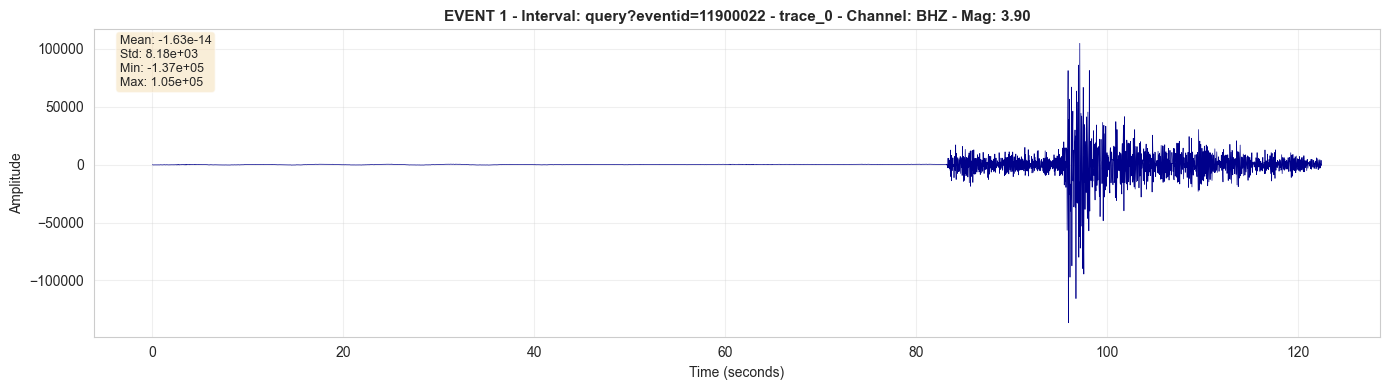

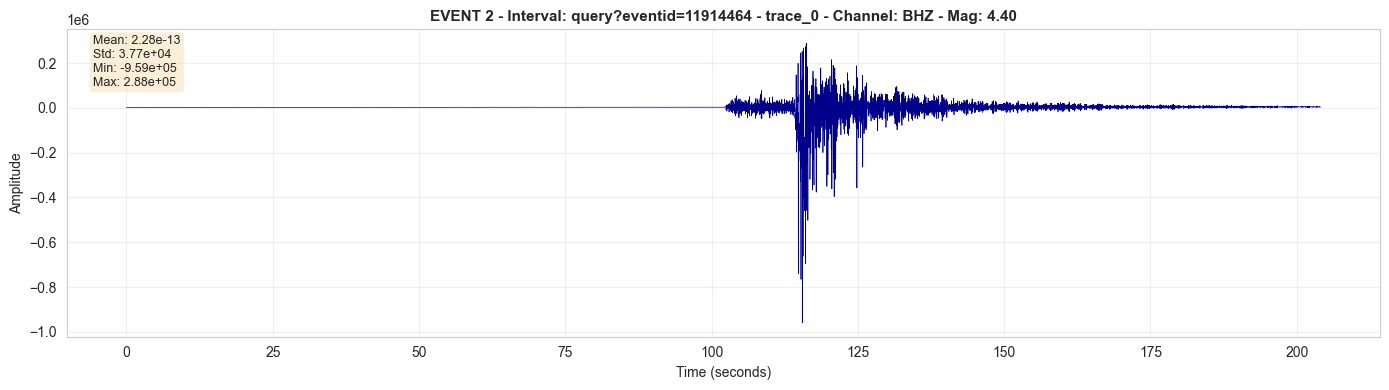

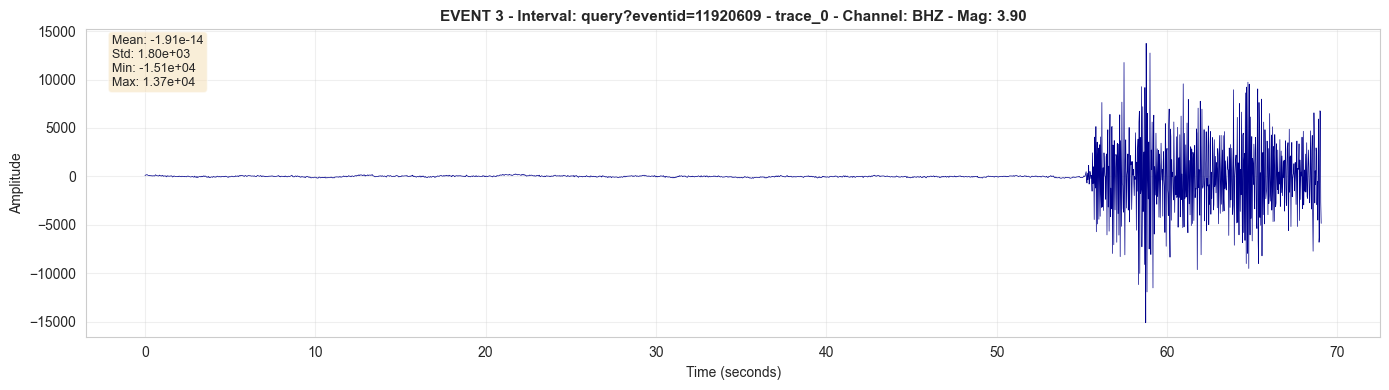

In [10]:
# Plot sample EVENT waveforms

print("=" * 70)
print("SAMPLE EVENT WAVEFORMS (Label = 1)")
print("=" * 70)

with h5py.File(hdf5_file, 'r') as hf:
    # Get event intervals
    event_intervals = []
    for sig_id in hf['signals'].keys():
        label = hf['signals'][sig_id].attrs.get('label', None)
        if label == 1:
            event_intervals.append(sig_id)
    
    print(f"\nTotal event intervals: {len(event_intervals)}")
    
    # Plot first 3 events
    num_to_plot = min(3, len(event_intervals))
    print(f"Plotting first {num_to_plot} events...\n")
    
    for i in range(num_to_plot):
        interval_id = event_intervals[i]
        plot_waveform(hf, interval_id, label_name=f'EVENT {i+1}', metadata_df=metadata_df)

SAMPLE NON-EVENT WAVEFORMS (Label = 0)

Total non-event intervals: 18
Plotting first 3 non-events...



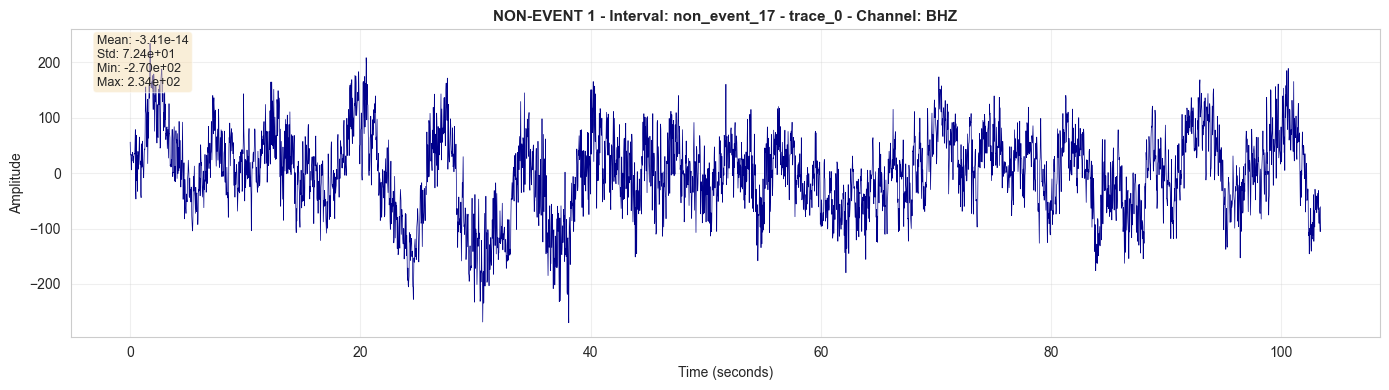

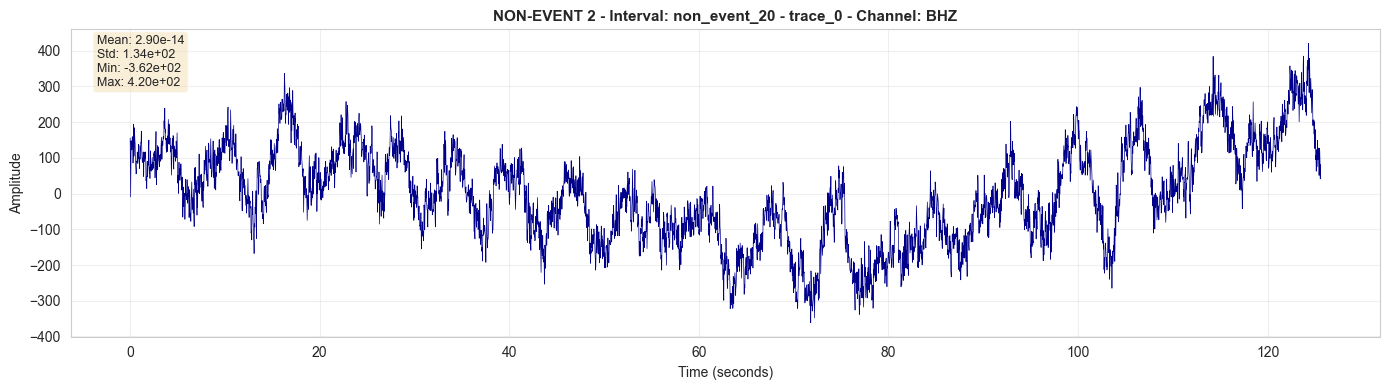

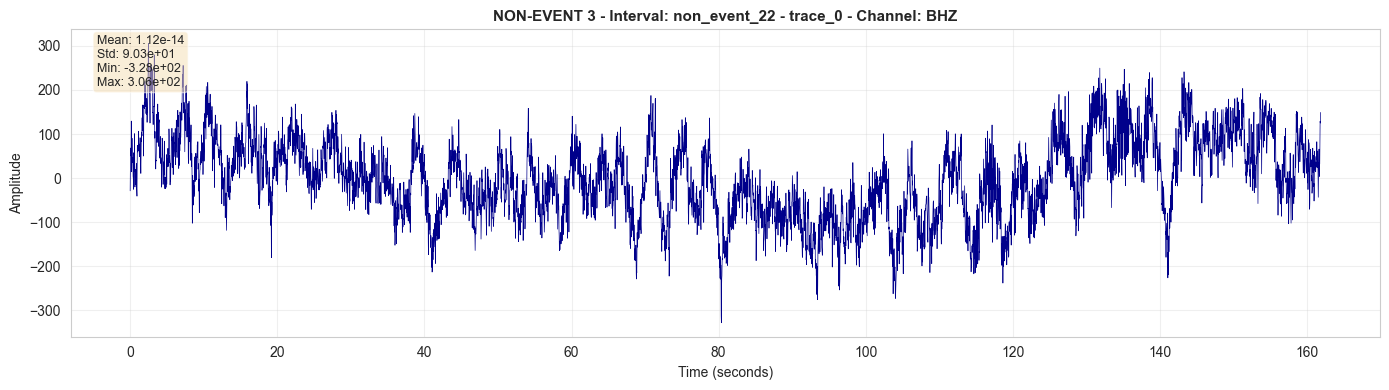

In [11]:
# Plot sample NON-EVENT waveforms

print("=" * 70)
print("SAMPLE NON-EVENT WAVEFORMS (Label = 0)")
print("=" * 70)

with h5py.File(hdf5_file, 'r') as hf:
    # Get non-event intervals
    non_event_intervals = []
    for sig_id in hf['signals'].keys():
        label = hf['signals'][sig_id].attrs.get('label', None)
        if label == 0:
            non_event_intervals.append(sig_id)
    
    print(f"\nTotal non-event intervals: {len(non_event_intervals)}")
    
    # Plot first 3 non-events
    num_to_plot = min(3, len(non_event_intervals))
    print(f"Plotting first {num_to_plot} non-events...\n")
    
    for i in range(num_to_plot):
        interval_id = non_event_intervals[i]
        plot_waveform(hf, interval_id, label_name=f'NON-EVENT {i+1}', metadata_df=metadata_df)

## Magnitude Analysis

Detailed analysis of earthquake magnitudes and their relationship with signal characteristics.

In [12]:
# Detailed Magnitude Analysis

print("=" * 70)
print("MAGNITUDE ANALYSIS")
print("=" * 70)

event_data = metadata_df[metadata_df['label'] == 1].copy()
event_signals_with_mag = signal_df[(signal_df['label'] == 1) & (signal_df['mag'].notna())].copy()

if len(event_data) > 0 and 'mag' in event_data.columns:
    mags = event_data['mag'].dropna()
    
    print(f"\n📊 Magnitude Statistics:")
    print(f"  Number of events with magnitude: {len(mags)}")
    print(f"  Range: {mags.min():.2f} - {mags.max():.2f}")
    print(f"  Mean: {mags.mean():.2f}")
    print(f"  Median: {mags.median():.2f}")
    print(f"  Std Dev: {mags.std():.2f}")
    
    # Magnitude bins
    bins = [mags.min(), 3.5, 4.0, 4.5, mags.max()]
    labels = ['Low (<3.5)', 'Medium (3.5-4.0)', 'Medium-High (4.0-4.5)', 'High (>4.5)']
    event_data['mag_category'] = pd.cut(event_data['mag'], bins=bins, labels=labels, include_lowest=True)
    
    print(f"\n📈 Magnitude Distribution by Category:")
    print(event_data['mag_category'].value_counts().sort_index())
    
    # Analyze signal characteristics by magnitude
    if len(event_signals_with_mag) > 0:
        print(f"\n🔬 Signal Characteristics by Magnitude:")
        
        # Create magnitude bins for signals
        event_signals_with_mag['mag_category'] = pd.cut(
            event_signals_with_mag['mag'], 
            bins=bins, 
            labels=labels, 
            include_lowest=True
        )
        
        print("\nMean Standard Deviation by Magnitude Category:")
        print(event_signals_with_mag.groupby('mag_category')['std_amplitude'].mean())
        
        print("\nMean Amplitude by Magnitude Category:")
        print(event_signals_with_mag.groupby('mag_category')['mean_amplitude'].mean())
        
        print("\nSignal Duration by Magnitude Category:")
        print(event_signals_with_mag.groupby('mag_category')['duration_s'].mean())
        
    # Correlation analysis
    if len(event_signals_with_mag) > 0:
        print(f"\n📊 Correlation Analysis:")
        corr_std = event_signals_with_mag[['mag', 'std_amplitude']].corr().iloc[0, 1]
        corr_mean = event_signals_with_mag[['mag', 'mean_amplitude']].corr().iloc[0, 1]
        print(f"  Magnitude vs Std Dev: {corr_std:.3f}")
        print(f"  Magnitude vs Mean Amplitude: {corr_mean:.3f}")

MAGNITUDE ANALYSIS

📊 Magnitude Statistics:
  Number of events with magnitude: 18
  Range: 3.40 - 5.70
  Mean: 4.46
  Median: 4.35
  Std Dev: 0.60

📈 Magnitude Distribution by Category:
mag_category
Low (<3.5)               1
Medium (3.5-4.0)         4
Medium-High (4.0-4.5)    8
High (>4.5)              5
Name: count, dtype: int64

🔬 Signal Characteristics by Magnitude:

Mean Standard Deviation by Magnitude Category:
mag_category
Low (<3.5)                   58.373009
Medium (3.5-4.0)           3003.680509
Medium-High (4.0-4.5)     10165.956215
High (>4.5)              469320.759151
Name: std_amplitude, dtype: float64

Mean Amplitude by Magnitude Category:
mag_category
Low (<3.5)               8.429610e-15
Medium (3.5-4.0)        -2.453556e-14
Medium-High (4.0-4.5)    6.251433e-14
High (>4.5)             -1.085078e-11
Name: mean_amplitude, dtype: float64

Signal Duration by Magnitude Category:
mag_category
Low (<3.5)                75.52500
Medium (3.5-4.0)          95.40625
Medium-Hig

C:\Users\aaron\AppData\Local\Temp\ipykernel_19440\87105592.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(event_signals_with_mag.groupby('mag_category')['std_amplitude'].mean())
C:\Users\aaron\AppData\Local\Temp\ipykernel_19440\87105592.py:44: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(event_signals_with_mag.groupby('mag_category')['mean_amplitude'].mean())
C:\Users\aaron\AppData\Local\Temp\ipykernel_19440\87105592.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or o

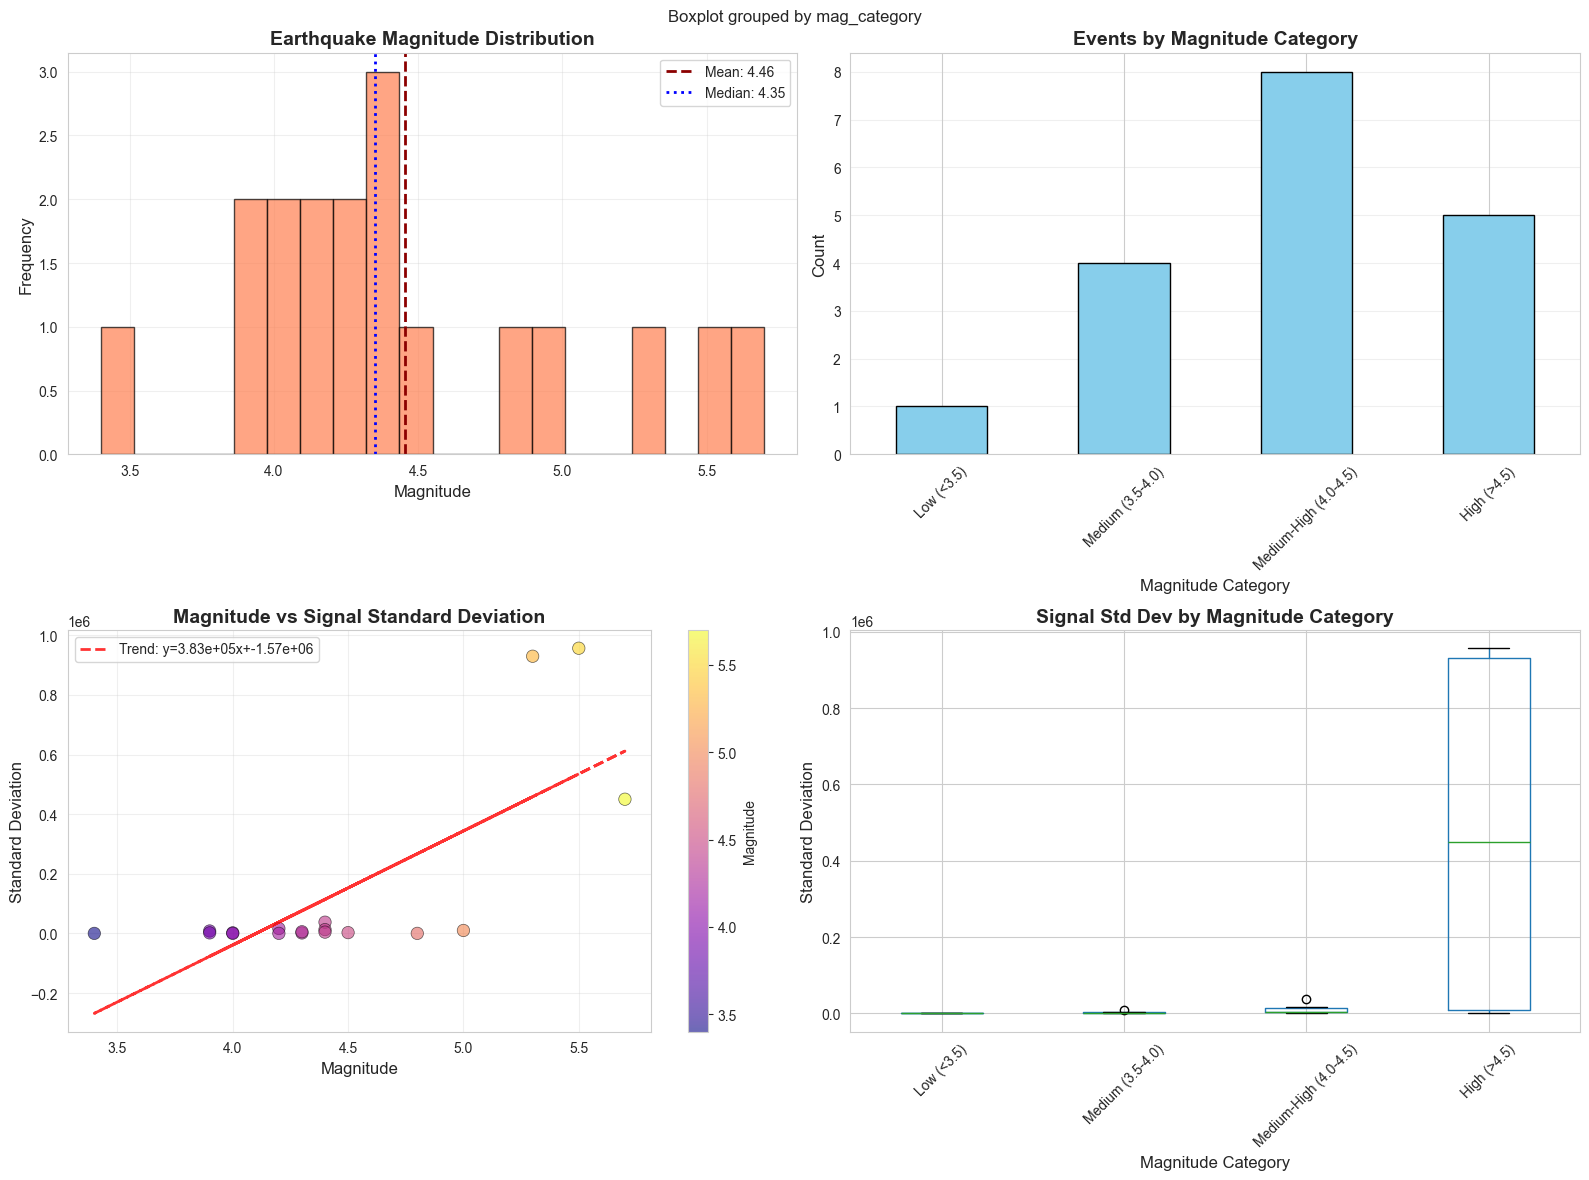

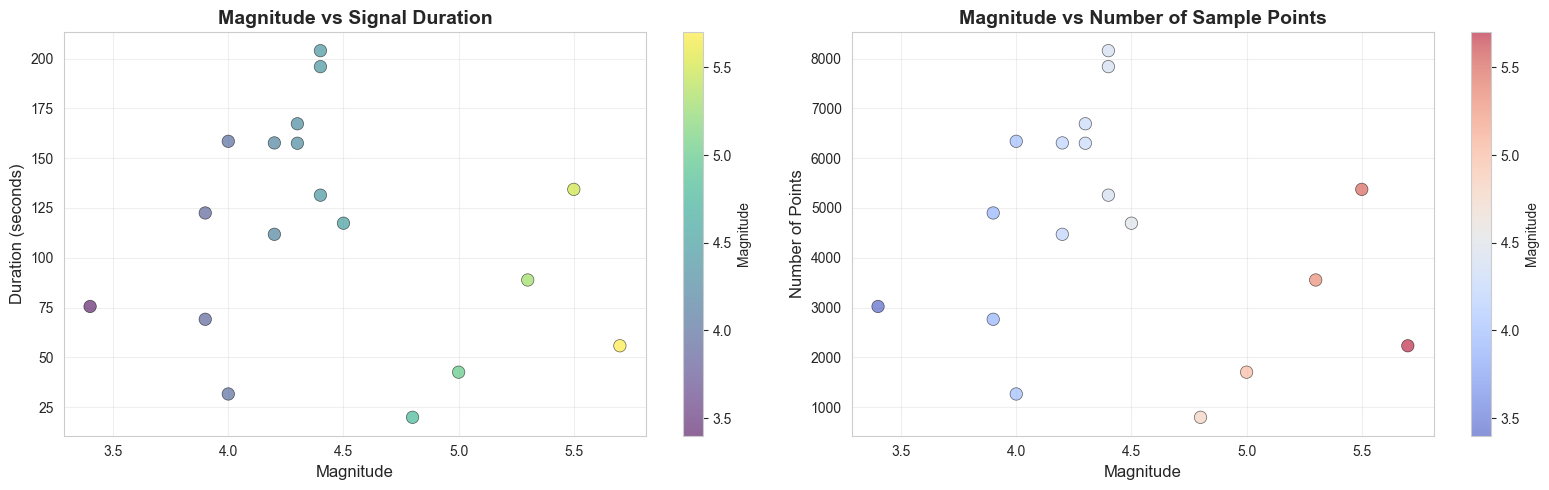

In [13]:
# Visualize Magnitude Relationships

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

if len(event_data) > 0 and 'mag' in event_data.columns:
    mags = event_data['mag'].dropna()
    
    # Magnitude histogram with categories
    axes[0, 0].hist(mags, bins=20, color='coral', edgecolor='black', alpha=0.7)
    axes[0, 0].axvline(mags.mean(), color='darkred', linestyle='--', linewidth=2,
                       label=f'Mean: {mags.mean():.2f}')
    axes[0, 0].axvline(mags.median(), color='blue', linestyle=':', linewidth=2,
                       label=f'Median: {mags.median():.2f}')
    axes[0, 0].set_title('Earthquake Magnitude Distribution', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Magnitude', fontsize=12)
    axes[0, 0].set_ylabel('Frequency', fontsize=12)
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Magnitude category bar plot
    if 'mag_category' in event_data.columns:
        mag_counts = event_data['mag_category'].value_counts().sort_index()
        mag_counts.plot(kind='bar', ax=axes[0, 1], color='skyblue', edgecolor='black')
        axes[0, 1].set_title('Events by Magnitude Category', fontsize=14, fontweight='bold')
        axes[0, 1].set_xlabel('Magnitude Category', fontsize=12)
        axes[0, 1].set_ylabel('Count', fontsize=12)
        axes[0, 1].tick_params(axis='x', rotation=45)
        axes[0, 1].grid(True, alpha=0.3, axis='y')

# Magnitude vs Signal Standard Deviation
if len(event_signals_with_mag) > 0:
    scatter1 = axes[1, 0].scatter(event_signals_with_mag['mag'], 
                                  event_signals_with_mag['std_amplitude'],
                                  c=event_signals_with_mag['mag'], 
                                  cmap='plasma', alpha=0.6, s=80, edgecolors='black', linewidth=0.5)
    axes[1, 0].set_title('Magnitude vs Signal Standard Deviation', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Magnitude', fontsize=12)
    axes[1, 0].set_ylabel('Standard Deviation', fontsize=12)
    axes[1, 0].grid(True, alpha=0.3)
    
    # Add trend line
    z = np.polyfit(event_signals_with_mag['mag'], event_signals_with_mag['std_amplitude'], 1)
    p = np.poly1d(z)
    axes[1, 0].plot(event_signals_with_mag['mag'], p(event_signals_with_mag['mag']), 
                    "r--", alpha=0.8, linewidth=2, label=f'Trend: y={z[0]:.2e}x+{z[1]:.2e}')
    axes[1, 0].legend()
    plt.colorbar(scatter1, ax=axes[1, 0], label='Magnitude')
    
    # Box plot: Signal characteristics by magnitude category
    if 'mag_category' in event_signals_with_mag.columns:
        event_signals_with_mag.boxplot(column='std_amplitude', by='mag_category', ax=axes[1, 1])
        axes[1, 1].set_title('Signal Std Dev by Magnitude Category', fontsize=14, fontweight='bold')
        axes[1, 1].set_xlabel('Magnitude Category', fontsize=12)
        axes[1, 1].set_ylabel('Standard Deviation', fontsize=12)
        axes[1, 1].tick_params(axis='x', rotation=45)
        plt.sca(axes[1, 1])

plt.tight_layout()
plt.show()

# Additional scatter plots
if len(event_signals_with_mag) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Magnitude vs Duration
    scatter2 = axes[0].scatter(event_signals_with_mag['mag'], 
                               event_signals_with_mag['duration_s'],
                               c=event_signals_with_mag['mag'], 
                               cmap='viridis', alpha=0.6, s=80, edgecolors='black', linewidth=0.5)
    axes[0].set_title('Magnitude vs Signal Duration', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Magnitude', fontsize=12)
    axes[0].set_ylabel('Duration (seconds)', fontsize=12)
    axes[0].grid(True, alpha=0.3)
    plt.colorbar(scatter2, ax=axes[0], label='Magnitude')
    
    # Magnitude vs Number of Points
    scatter3 = axes[1].scatter(event_signals_with_mag['mag'], 
                               event_signals_with_mag['num_points'],
                               c=event_signals_with_mag['mag'], 
                               cmap='coolwarm', alpha=0.6, s=80, edgecolors='black', linewidth=0.5)
    axes[1].set_title('Magnitude vs Number of Sample Points', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Magnitude', fontsize=12)
    axes[1].set_ylabel('Number of Points', fontsize=12)
    axes[1].grid(True, alpha=0.3)
    plt.colorbar(scatter3, ax=axes[1], label='Magnitude')
    
    plt.tight_layout()
    plt.show()

## Temporal Analysis

Analyze the distribution of events and non-events over time.

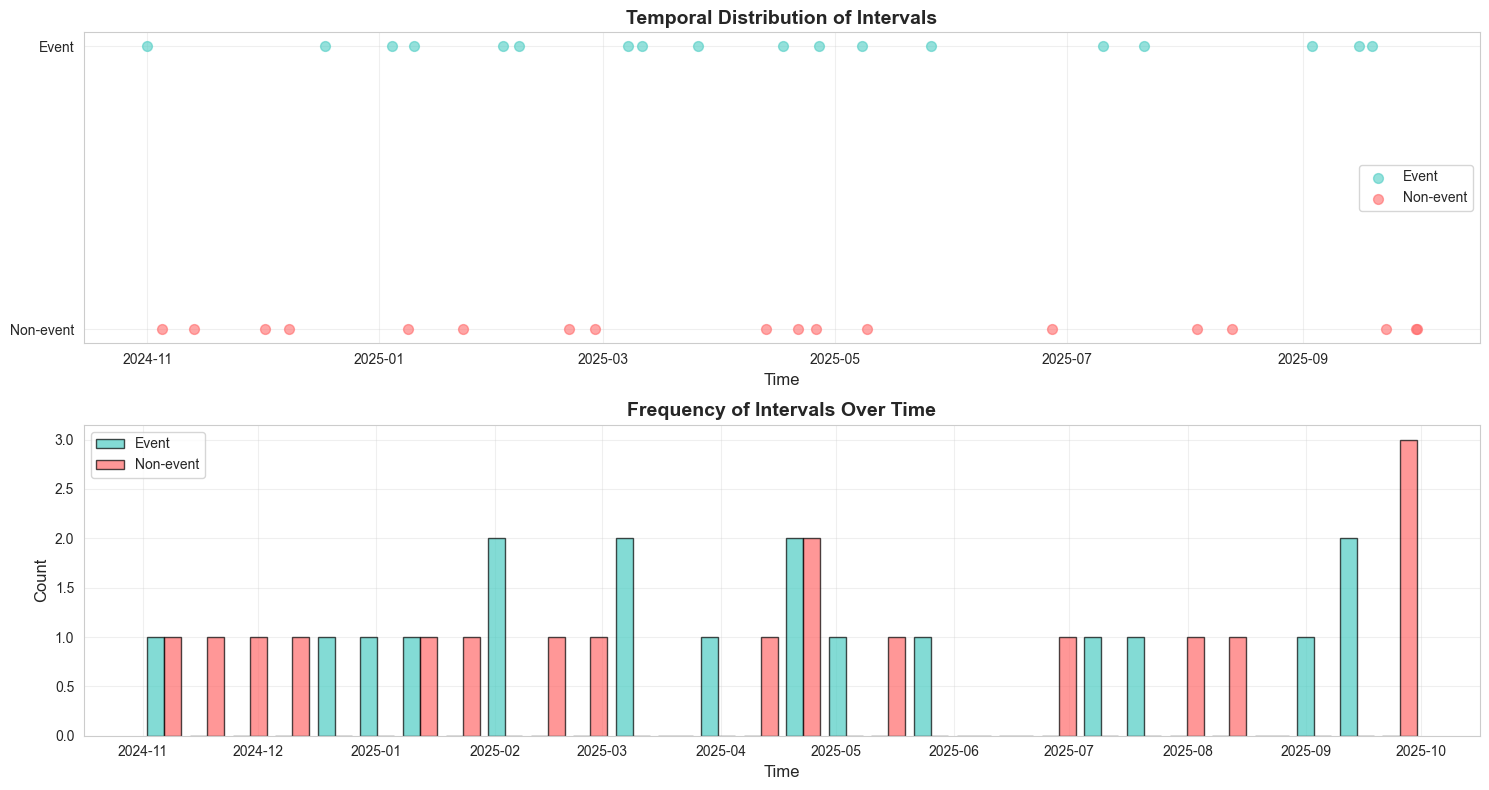

📅 Temporal Statistics:

Time range: 2024-11-01 01:25:26.317901 to 2025-09-30 21:03:42.784867
Total span: 333 days


In [14]:
# Temporal distribution of intervals

if 'start_time' in metadata_df.columns:
    fig, axes = plt.subplots(2, 1, figsize=(15, 8))
    
    # Timeline of all intervals
    event_data = metadata_df[metadata_df['label'] == 1].sort_values('start_time')
    non_event_data = metadata_df[metadata_df['label'] == 0].sort_values('start_time')
    
    axes[0].scatter(event_data['start_time'], [1]*len(event_data), 
                   color='#4ECDC4', alpha=0.6, s=50, label='Event')
    axes[0].scatter(non_event_data['start_time'], [0]*len(non_event_data), 
                   color='#FF6B6B', alpha=0.6, s=50, label='Non-event')
    axes[0].set_title('Temporal Distribution of Intervals', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Time', fontsize=12)
    axes[0].set_yticks([0, 1])
    axes[0].set_yticklabels(['Non-event', 'Event'])
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Histogram of events over time
    axes[1].hist([event_data['start_time'], non_event_data['start_time']], 
                bins=30, label=['Event', 'Non-event'], 
                color=['#4ECDC4', '#FF6B6B'], alpha=0.7, edgecolor='black')
    axes[1].set_title('Frequency of Intervals Over Time', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Time', fontsize=12)
    axes[1].set_ylabel('Count', fontsize=12)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("📅 Temporal Statistics:")
    print(f"\nTime range: {metadata_df['start_time'].min()} to {metadata_df['start_time'].max()}")
    print(f"Total span: {(metadata_df['start_time'].max() - metadata_df['start_time'].min()).days} days")

## Summary and Key Findings

This section summarizes the main observations from the AED.

In [15]:
# Generate summary report

print("=" * 70)
print("COMPREHENSIVE SUMMARY REPORT")
print("=" * 70)

print("\n📊 DATASET OVERVIEW:")
print(f"  Total intervals: {len(metadata_df)}")
print(f"  Event intervals (label=1): {len(metadata_df[metadata_df['label']==1])}")
print(f"  Non-event intervals (label=0): {len(metadata_df[metadata_df['label']==0])}")
print(f"  HDF5 file size: {file_size_mb:.2f} MB")

if 'duration' in metadata_df.columns:
    print("\n⏱️ DURATION CHARACTERISTICS:")
    print(f"  Overall range: {metadata_df['duration'].min():.1f}s - {metadata_df['duration'].max():.1f}s")
    print(f"  Overall mean: {metadata_df['duration'].mean():.1f}s ± {metadata_df['duration'].std():.1f}s")
    print(f"  Event mean duration: {metadata_df[metadata_df['label']==1]['duration'].mean():.1f}s")
    print(f"  Non-event mean duration: {metadata_df[metadata_df['label']==0]['duration'].mean():.1f}s")

if len(signal_df) > 0:
    print("\n📡 SIGNAL PROPERTIES:")
    print(f"  Total traces: {len(signal_df)}")
    print(f"  Sampling rate: {signal_df['sampling_rate'].mode()[0]:.1f} Hz")
    print(f"  Mean points per trace: {signal_df['num_points'].mean():.0f}")
    
    print("\n📈 AMPLITUDE CHARACTERISTICS:")
    print(f"  Event signals - Mean std: {signal_df[signal_df['label']==1]['std_amplitude'].mean():.2e}")
    print(f"  Non-event signals - Mean std: {signal_df[signal_df['label']==0]['std_amplitude'].mean():.2e}")

if 'mag' in metadata_df.columns:
    event_mags = metadata_df[metadata_df['label']==1]['mag'].dropna()
    if len(event_mags) > 0:
        print("\n🌍 EVENT MAGNITUDES:")
        print(f"  Range: {event_mags.min():.2f} - {event_mags.max():.2f}")
        print(f"  Mean: {event_mags.mean():.2f} ± {event_mags.std():.2f}")

if 'start_time' in metadata_df.columns:
    print("\n📅 TEMPORAL COVERAGE:")
    print(f"  Start: {metadata_df['start_time'].min()}")
    print(f"  End: {metadata_df['start_time'].max()}")
    time_span = (metadata_df['start_time'].max() - metadata_df['start_time'].min()).days
    print(f"  Total span: {time_span} days ({time_span/30:.1f} months)")

COMPREHENSIVE SUMMARY REPORT

📊 DATASET OVERVIEW:
  Total intervals: 36
  Event intervals (label=1): 18
  Non-event intervals (label=0): 18
  HDF5 file size: 1.36 MB

⏱️ DURATION CHARACTERISTICS:
  Overall range: 19.8s - 204.1s
  Overall mean: 109.5s ± 49.1s
  Event mean duration: 113.4s
  Non-event mean duration: 105.5s

📡 SIGNAL PROPERTIES:
  Total traces: 36
  Sampling rate: 40.0 Hz
  Mean points per trace: 4378

📈 AMPLITUDE CHARACTERISTICS:
  Event signals - Mean std: 1.36e+05
  Non-event signals - Mean std: 9.81e+01

🌍 EVENT MAGNITUDES:
  Range: 3.40 - 5.70
  Mean: 4.46 ± 0.60

📅 TEMPORAL COVERAGE:
  Start: 2024-11-01 01:25:26.317901
  End: 2025-09-30 21:03:42.784867
  Total span: 333 days (11.1 months)
